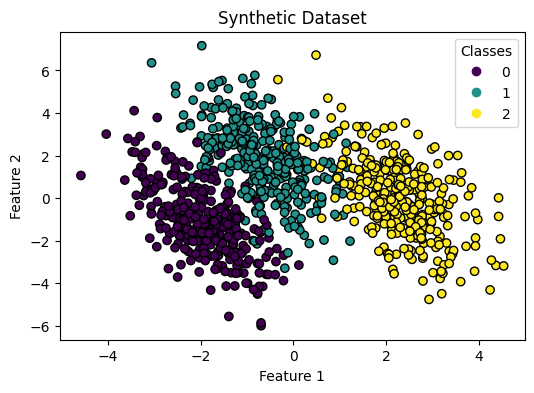

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs

centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1000, centers=centers, random_state=16, cluster_std=1.4)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)

fig, ax = plt.subplots(figsize=(6, 4))

scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black")
ax.set(title="Synthetic Dataset", xlabel="Feature 1", ylabel="Feature 2")
_ = ax.legend(*scatter.legend_elements(), title="Classes")

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

logistic_regression_multinomial = LogisticRegression().fit(X, y)
logistic_regression_ovr = OneVsRestClassifier(LogisticRegression()).fit(X, y)

accuracy_multinomial = logistic_regression_multinomial.score(X, y)
accuracy_ovr = logistic_regression_ovr.score(X, y)

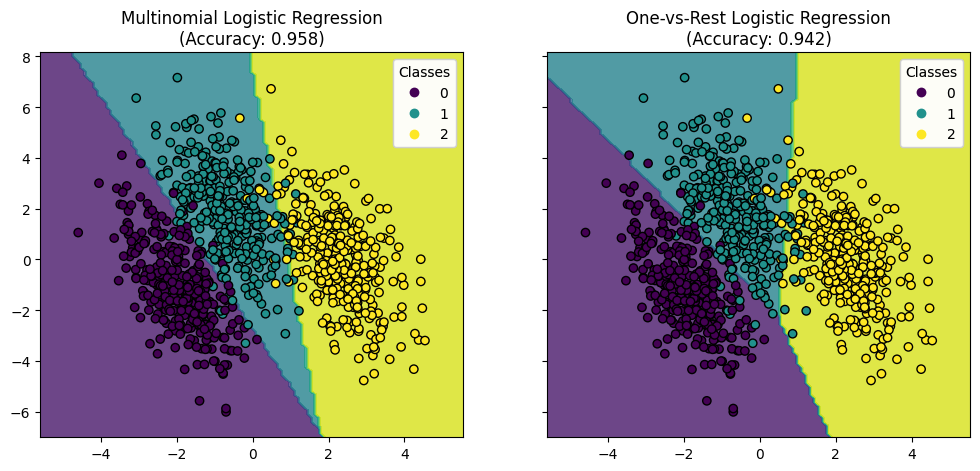

In [4]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for model, title, ax in [
    (
        logistic_regression_multinomial,
        f"Multinomial Logistic Regression\n(Accuracy: {accuracy_multinomial:.3f})",
        ax1,
    ),
    (
        logistic_regression_ovr,
        f"One-vs-Rest Logistic Regression\n(Accuracy: {accuracy_ovr:.3f})",
        ax2,
    ),
]:
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        ax=ax,
        response_method="predict",
        alpha=0.8,
    )
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    legend = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend)
    ax.set_title(title)

In [5]:
def plot_hyperplanes(classifier, X, ax):
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))

    if isinstance(classifier, OneVsRestClassifier):
        coef = np.concatenate([est.coef_ for est in classifier.estimators_])
        intercept = np.concatenate([est.intercept_ for est in classifier.estimators_])
    else:
        coef = classifier.coef_
        intercept = classifier.intercept_

    for i in range(coef.shape[0]):
        w = coef[i]
        a = -w[0] / w[1]
        xx = np.linspace(xmin, xmax)
        yy = a * xx - (intercept[i]) / w[1]
        ax.plot(xx, yy, "--", linewidth=3, label=f"Class {i}")

    return ax.get_legend_handles_labels()

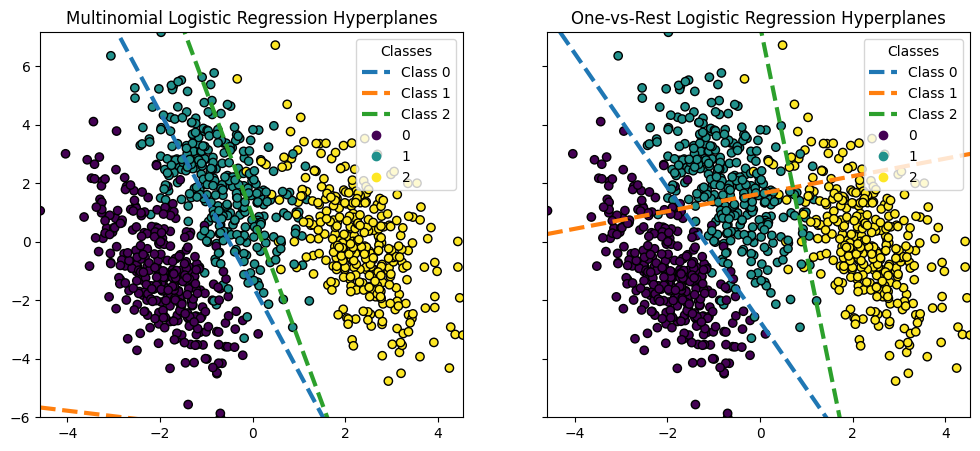

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for model, title, ax in [
    (
        logistic_regression_multinomial,
        "Multinomial Logistic Regression Hyperplanes",
        ax1,
    ),
    (logistic_regression_ovr, "One-vs-Rest Logistic Regression Hyperplanes", ax2),
]:
    hyperplane_handles, hyperplane_labels = plot_hyperplanes(model, X, ax)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    scatter_handles, scatter_labels = scatter.legend_elements()

    all_handles = hyperplane_handles + scatter_handles
    all_labels = hyperplane_labels + scatter_labels

    ax.legend(all_handles, all_labels, title="Classes")
    ax.set_title(title)

plt.show()

In [7]:
centers= [[ 0, -3, -3, -3,  0, -3, -1, -2, -3,  0], [ 1, -1, -1,  0,  0, -1, -2,  1,  0,  0], [2, 1, 2, 2, 1, 1, 2, 1, 2, 2]]

X, y = make_blobs(n_samples=1000, centers=centers, random_state=16, cluster_std=1.5)
teacher_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# Fit the model to the Iris dataset
teacher_model.fit(X, y)

# Calculate and print the training accuracy
training_accuracy = teacher_model.score(X, y)
print(f"Logistic Regression Training Accuracy: {training_accuracy:.4f}")

Logistic Regression Training Accuracy: 0.9860


./.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
teacher_dir = f'./models/teacher/{dset}.tar'
if not os.path.exists(teacher_dir):
    state = Method.model.module.state_dict() if hasattr(Method.model, 'module') else Method.model.state_dict()
    torch.save(state, teacher_dir)